In [2]:
!pip install photutils

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.nddata import NDData
from astropy.visualization import simple_norm
from photutils.detection import find_peaks
from photutils.psf import EPSFBuilder, extract_stars
from photutils.psf import IntegratedGaussianPRF
from photutils.aperture import CircularAperture
from astropy.table import Table
from astropy.modeling import models, fitting

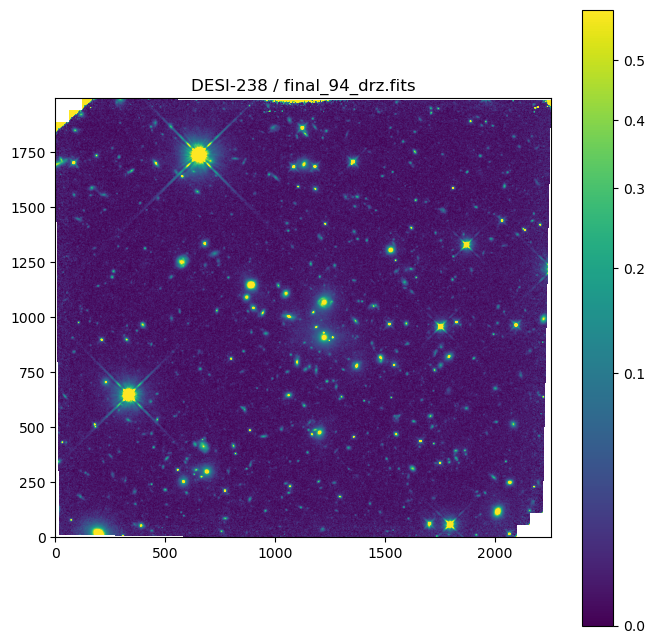

In [4]:
# visualize data
f = fits.open('final_94_drz.fits')
imR = f[1].data
f.close()
imR[imR < 0] = 0
norm = simple_norm(imR, 'sqrt', percent=99.)
plt.figure(figsize=(8,8))
plt.imshow(imR, origin='lower', norm=norm, cmap='viridis')
plt.title('DESI-238 / final_94_drz.fits')
plt.colorbar()
plt.show()

# PSF

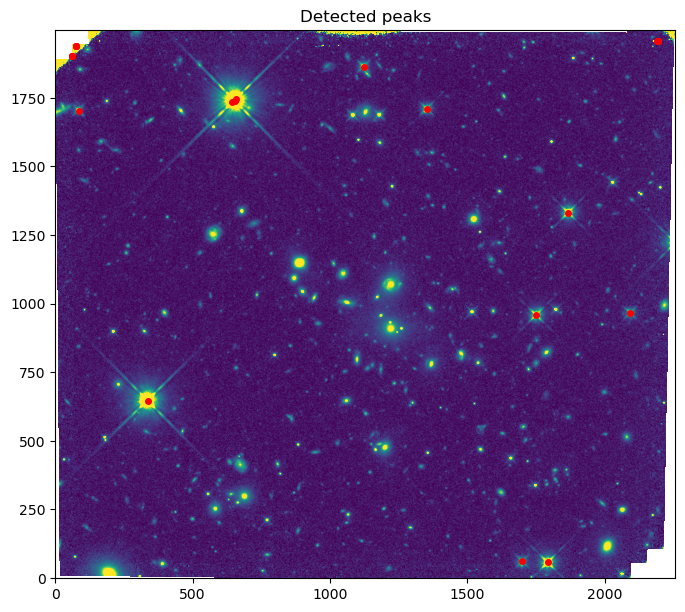

 x    y   peak_value
---- ---- ----------
 653 1738   8053.397
 337  646   4277.166
1795   57  599.11743
  75 1938   591.5604
  76 1939   591.5604
  75 1939   591.5604
  76 1938   591.5604
2193 1957  487.03494
2194 1957  487.03494
2193 1956  487.03494
 ...  ...        ...
  59 1901    87.7527
  60 1900    87.7527
  59 1900    87.7527
2191 1955    78.3118
2094  964   72.17982
1701   61   69.84441
1123 1861   64.33475
  85 1702  59.653767
 657 1745  55.949238
1353 1707   54.34452
 645 1734  51.956333
Length = 25 rows


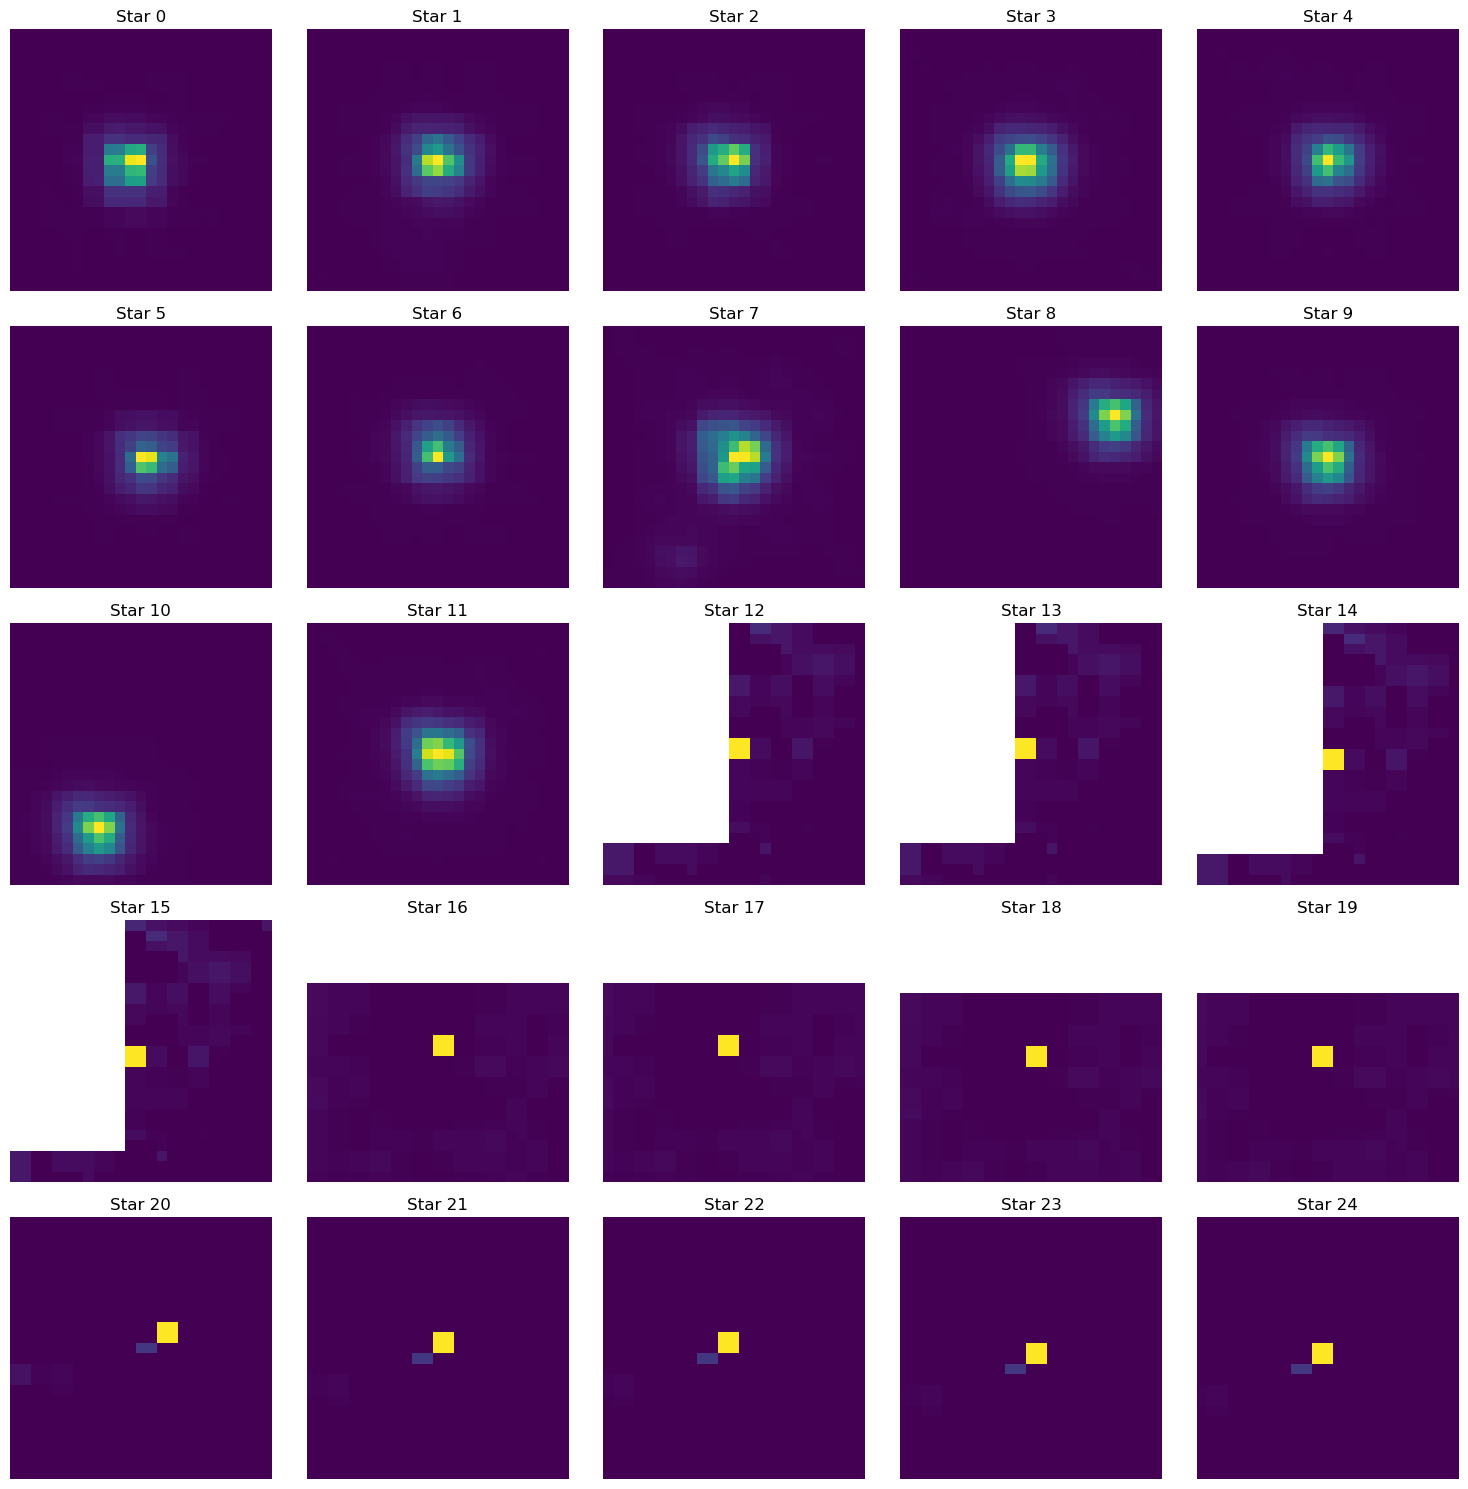

In [5]:
# find peaks in brightness
threshold = 50
peaks_tbl = find_peaks(imR, threshold=threshold)
# print(peaks_tbl)

# show detected stars
plt.figure(figsize=(8,8))
plt.imshow(imR, origin='lower', cmap='viridis', norm=norm)
plt.title('Detected peaks')
plt.plot(peaks_tbl['x_peak'], peaks_tbl['y_peak'], 'ro', markersize=4)
plt.show()

catalog = Table()
catalog['x'] = peaks_tbl['x_peak']
catalog['y'] = peaks_tbl['y_peak']
stars = extract_stars(NDData(imR), catalog, size=25)
catalog['peak_value'] = peaks_tbl['peak_value']
catalog.sort('peak_value', reverse=True)
print(catalog)

n_stars = len(stars)
n_cols = 5
n_rows = np.ceil(n_stars // n_cols)
fig, axes = plt.subplots(int(n_rows), int(n_cols), figsize=(n_cols*3, n_rows*3))
for i, star in enumerate(stars):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    im = ax.imshow(star.data, origin='lower', cmap='viridis')
    ax.set_title(f'Star {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# extract stars i want
stars_to_use = stars[:11]

EPSFBuilder (1 maxiters):   0%|          | 0/1 [00:00<?, ?it/s]

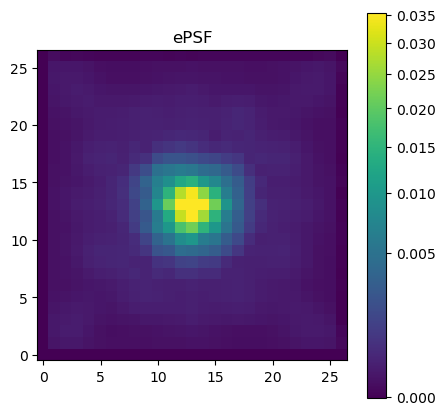

In [7]:
# build epsf
builder = EPSFBuilder(maxiters=1, oversampling=1)
epsf, fitted_stars = builder.build_epsf(stars_to_use)
psf_array = epsf.data.astype(np.float32)
np.save('psf.npy', psf_array)

# visualize epsf
plt.figure(figsize=(5,5))
plt.imshow(epsf.data, origin='lower', norm=simple_norm(epsf.data, 'sqrt', percent=99.), cmap='viridis')
plt.colorbar()
plt.title('ePSF')
plt.show()

# Sersic profiles

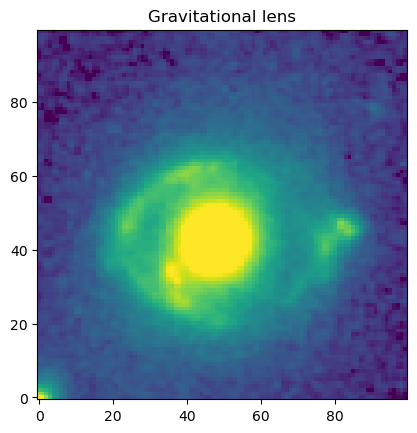

In [8]:
from astropy.nddata import Cutout2D

ny, nx = imR.shape
center = (1225, 1075)
cutout_size = (100, 100)
cutout = Cutout2D(imR, position=center, size=cutout_size)
imL = np.nan_to_num(cutout.data, nan=0.0, posinf=0.0, neginf=0.0)
ny, nx = imL.shape
py, px = np.mgrid[:ny, :nx]
plt.imshow(imL, origin='lower', cmap='viridis', norm=norm)
plt.title("Gravitational lens")
plt.show()

position of lens center: 48 42


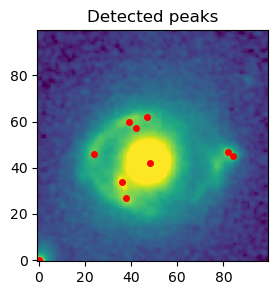

In [9]:
threshold = 0.35
lens_peaks = find_peaks(imL, threshold=threshold)
lens_peaks.sort('peak_value', reverse=True)
cx, cy = lens_peaks['x_peak'][0], lens_peaks['y_peak'][0]
print('position of lens center:', cx, cy)
plt.figure(figsize=(3,3))
plt.imshow(imL, origin='lower', cmap='viridis', norm=norm)
plt.title('Detected peaks')
plt.plot(lens_peaks['x_peak'], lens_peaks['y_peak'], 'ro', markersize=4)
plt.show()

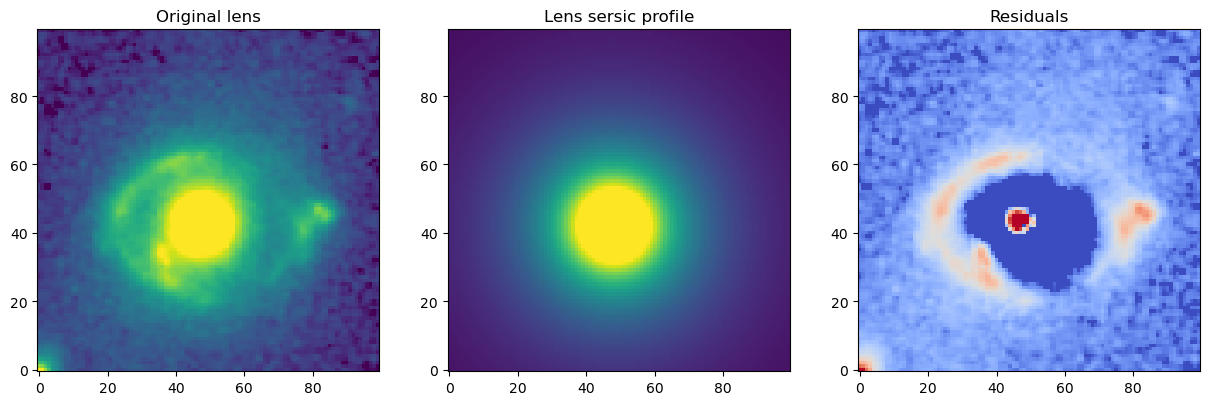

In [10]:
lens_init = models.Sersic2D(amplitude=imL.max()/2, r_eff=15.0, n=4.0, x_0=cx, y_0=cy, ellip=0.2, theta=0.0)

fit_p = fitting.LevMarLSQFitter()
best_lens_model = fit_p(lens_init, px, py, imL)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(imL, origin='lower', cmap='viridis', norm=norm)
plt.title("Original lens")
plt.subplot(1,3,2)
plt.imshow(best_lens_model(px, py), origin='lower', cmap='viridis', norm=norm)
plt.title("Lens sersic profile")
plt.subplot(1,3,3)
res = imL - best_lens_model(px, py)
plt.imshow(res, origin='lower', norm=norm, cmap='coolwarm')
plt.title("Residuals")
plt.show()

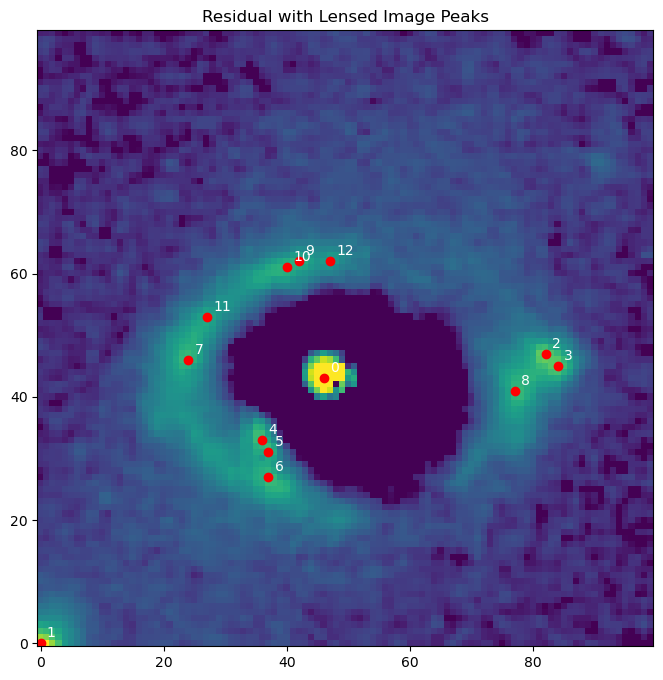

 id x_peak y_peak      peak_value    
--- ------ ------ -------------------
  6     46     43  1.6667699019959947
  1      0      0  0.7377649061979233
  9     82     47 0.36564288939605594
  7     84     45  0.3458133571766106
  4     36     33  0.2825686284540998
  3     37     31   0.279209753817285
  2     37     27  0.2718493901133298
  8     24     46 0.26757080975471653
  5     77     41 0.26513278432476584
 12     42     62 0.24584209406209803
 11     40     61 0.24547342652056126
 10     27     53 0.21323713745256154
 13     47     62 0.20487573478686738


In [11]:
threshold = 0.2
res_peaks = find_peaks(res, threshold=threshold)
res_peaks.sort('peak_value', reverse=True)

plt.figure(figsize=(8,8))
plt.imshow(res, origin='lower', cmap='viridis', norm=norm)
plt.title('Residual with Lensed Image Peaks')
positions = np.column_stack((res_peaks['x_peak'], res_peaks['y_peak']))
for i, (x, y) in enumerate(zip(res_peaks['x_peak'], res_peaks['y_peak'])):
    plt.plot(x, y, 'ro')
    plt.text(x+1, y+1, str(i), color='white', fontsize=10)
plt.show()
print(res_peaks)

In [12]:
qsrc_pos = positions[[7, 10, 8, 6]]
dsrc_pos = positions[[4, 3]]
print('quad source positions:', qsrc_pos, '\nduo source positions:', dsrc_pos)

quad source positions: [[24 46]
 [40 61]
 [77 41]
 [37 27]] 
duo source positions: [[36 33]
 [84 45]]


In [13]:
np.save('imL.npy', imL) # 100x100

In [14]:
center_row, center_col = imL.shape[0]//2, imL.shape[1]//2
imL_60x60 = imL[center_row-30:center_row+30,center_col-30:center_col+30]
np.save('imL_60x60', imL_60x60)